# PART A

DOMAIN: Electronics and Telecommunication

• CONTEXT: A communications equipment manufacturing company has a product which is responsible for emitting informative signals.Company wants to build a machine learning model which can help the company to predict the equipment’s signal quality using various parameters.

• DATA DESCRIPTION: The data set contains information on various signal tests performed:

1. Parameters: Various measurable signal parameters.

2. Signal_Quality: Final signal strength or quality

• PROJECT OBJECTIVE: To build a classifier which can use the given parameters to determine the signal strength or quality

In [1]:
%tensorflow_version 2.x

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [54]:
# 1. Data import and Understanding
# A. Read the ‘Signals.csv’ as DataFrame and import required libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow 
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization,Dropout
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense, Flatten
import warnings

warnings.filterwarnings('ignore')

In [5]:
tensorflow.__version__

'2.12.0'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
%cd /content/drive/MyDrive/NN_Project/deep_learning/

/content/drive/MyDrive/NN_Project/deep_learning


In [12]:
# 1. Data import and Understanding
# A. Read the ‘Signals.csv’ as DataFrame and import required libraries.
data = pd.read_csv('NN Project Data - Signal.csv')
data.head()

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
# 1. Data import and Understanding
# B. Check for missing values and print percentage for each attribute.
data.isnull().sum()/len(data)*100

Parameter 1        0.0
Parameter 2        0.0
Parameter 3        0.0
Parameter 4        0.0
Parameter 5        0.0
Parameter 6        0.0
Parameter 7        0.0
Parameter 8        0.0
Parameter 9        0.0
Parameter 10       0.0
Parameter 11       0.0
Signal_Strength    0.0
dtype: float64

In [14]:
# 1. Data import and Understanding
# C. Check for presence of duplicate records in the dataset and impute with appropriate method.
print(data.duplicated().sum())
print("Data shape:", data.shape)
data.drop_duplicates(keep='first',inplace=True)
print("Data shape:", data.shape)
print(data.duplicated().sum())

240
Data shape: (1599, 12)
Data shape: (1359, 12)
0


<Axes: >

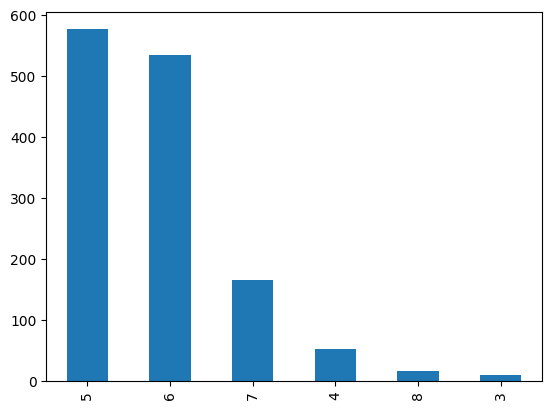

In [15]:
# 1. Data import and Understanding
# D. Visualise distribution of the target variable.
data['Signal_Strength'].value_counts().plot(kind='bar')

# 1. Data import and Understanding
# E. Share insights from the initial data analysis

Observation 1: Class 5 has the signal highest count

Observation 2: Class 3 has the lowest count

Observation 3: Signal strength is biased towards 5 & 6

Observation 4: Range of sensors is different for different attributes. Normalization is needed here.

In [16]:
# 2. Data preprocessing
# A. Split the data into X & Y.
X = data.drop('Signal_Strength',axis=1)
Y = data['Signal_Strength']    

In [17]:
# 2. Data preprocessing
# B. Split the data into train & test with 70:30 proportion.
X_Train,X_Test,Y_Train,Y_Test = train_test_split(X, Y, train_size=0.7, random_state=12)

In [18]:
# 2. Data preprocessing
# C. Print shape of all the 4 variables and verify if train and test data is in sync.
print("Shape of X_train:", X_Train.shape)
print("Shape of X_test:", X_Test.shape)
print("Shape of y_train:", Y_Train.shape)
print("Shape of y_test:", Y_Test.shape)

Shape of X_train: (951, 11)
Shape of X_test: (408, 11)
Shape of y_train: (951,)
Shape of y_test: (408,)


In [19]:
# 2. Data preprocessing
# D. Normalise the train and test data with appropriate method.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_Train)
X_Train_Scaler = scaler.transform(X_Train)
X_Test_Scaler = scaler.transform(X_Test)   

In [20]:
# 2. Data preprocessing
# E. Transform Labels into format acceptable by Neural Network
Y_Train = tf.keras.utils.to_categorical(Y_Train)
Y_Test = tf.keras.utils.to_categorical(Y_Test)

In [22]:
# 3. Model Training & Evaluation using Neural Network
# A. Design a Neural Network to train a classifier.
NN_Regressor = Sequential()

NN_Regressor.add(Dense(11, kernel_initializer='normal',input_dim = X_Train.shape[1], activation='relu'))
NN_Regressor.add(BatchNormalization())

NN_Regressor.add(Dense(9,activation='relu'))
NN_Regressor.add(Dense(9,activation='softmax'))  # except softmax

NN_Regressor.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
NN_Regressor.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                132       
                                                                 
 batch_normalization (BatchN  (None, 11)               44        
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             (None, 9)                 108       
                                                                 
 dense_2 (Dense)             (None, 9)                 90        
                                                                 
Total params: 374
Trainable params: 352
Non-trainable params: 22
_________________________________________________________________


In [24]:
# 3. Model Training & Evaluation using Neural Network
# B. Train the classifier using previously designed Architecture
NN_Regressor.compile(loss='mean_absolute_error', optimizer='adam', metrics=['MeanSquaredError'])
trained_model = NN_Regressor.fit(X_Train_Scaler, Y_Train, validation_data=(X_Test_Scaler,Y_Test), epochs=100, batch_size=128)

Epoch 1/100
8/8 [==============================] - 2s 37ms/step - loss: 0.1944 - mean_squared_error: 0.0990 - val_loss: 0.1964 - val_mean_squared_error: 0.0978
Epoch 2/100
8/8 [==============================] - 0s 10ms/step - loss: 0.1910 - mean_squared_error: 0.0959 - val_loss: 0.1955 - val_mean_squared_error: 0.0969
Epoch 3/100
8/8 [==============================] - 0s 7ms/step - loss: 0.1874 - mean_squared_error: 0.0929 - val_loss: 0.1945 - val_mean_squared_error: 0.0959
Epoch 4/100
8/8 [==============================] - 0s 7ms/step - loss: 0.1831 - mean_squared_error: 0.0898 - val_loss: 0.1934 - val_mean_squared_error: 0.0949
Epoch 5/100
8/8 [==============================] - 0s 9ms/step - loss: 0.1784 - mean_squared_error: 0.0870 - val_loss: 0.1920 - val_mean_squared_error: 0.0936
Epoch 6/100
8/8 [==============================] - 0s 8ms/step - loss: 0.1736 - mean_squared_error: 0.0849 - val_loss: 0.1904 - val_mean_squared_error: 0.0922
Epoch 7/100
8/8 [===========================

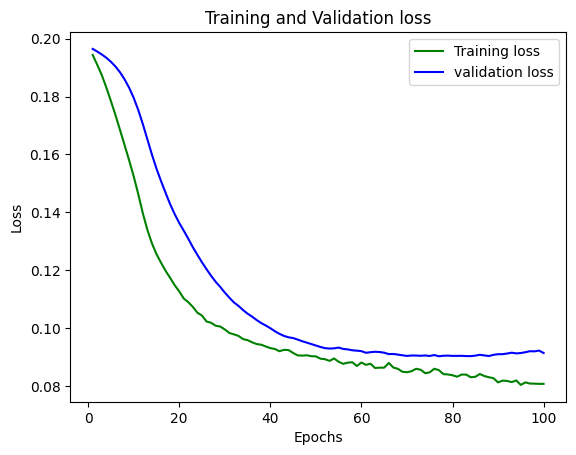

In [25]:
# 3. Model Training & Evaluation using Neural Network
# C. Plot 2 separate visuals.
# i. Training Loss and Validation Loss
loss_train = NN_Regressor.history.history['loss']
loss_val = NN_Regressor.history.history['val_loss']
epochs = range(1,100+1)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

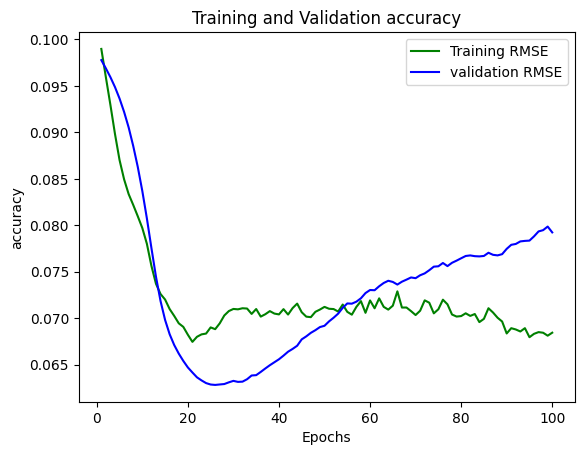

In [27]:
# 3. Model Training & Evaluation using Neural Network
# C. Plot 2 separate visuals.
# Acc_train = NN_model_Regressor.history.history['mean_squared_error']
Acc_train = NN_Regressor.history.history['mean_squared_error']
Acc_val = NN_Regressor.history.history['val_mean_squared_error']
epochs = range(1,100+1)
plt.plot(epochs, Acc_train, 'g', label='Training RMSE')
plt.plot(epochs, Acc_val, 'b', label='validation RMSE')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [28]:
# 3. Model Training & Evaluation using Neural Network
# D. Design new architecture/update existing architecture in attempt to improve the performance of the model.
model = Sequential()

model.add(Dense(11, kernel_initializer='normal',input_dim = X_Train.shape[1], activation='relu'))
model.add(BatchNormalization())

model.add(Dense(9,activation='relu'))

model.add(Dense(9,activation='relu'))
model.add(Dense(9,activation='softmax')) 

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 11)                132       
                                                                 
 batch_normalization_1 (Batc  (None, 11)               44        
 hNormalization)                                                 
                                                                 
 dense_4 (Dense)             (None, 9)                 108       
                                                                 
 dense_5 (Dense)             (None, 9)                 90        
                                                                 
 dense_6 (Dense)             (None, 9)                 90        
                                                                 
Total params: 464
Trainable params: 442
Non-trainable params: 22
_______________________________________________________

In [29]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics='accuracy')
trained_model = model.fit(X_Train_Scaler, Y_Train, validation_data=(X_Test_Scaler,Y_Test), epochs=100, batch_size=32)

Epoch 1/100
30/30 [==============================] - 2s 11ms/step - loss: 2.5213 - accuracy: 0.0705 - val_loss: 2.1449 - val_accuracy: 0.4265
Epoch 2/100
30/30 [==============================] - 0s 4ms/step - loss: 2.1443 - accuracy: 0.2744 - val_loss: 2.0784 - val_accuracy: 0.4289
Epoch 3/100
30/30 [==============================] - 0s 4ms/step - loss: 1.9100 - accuracy: 0.4469 - val_loss: 1.9920 - val_accuracy: 0.4265
Epoch 4/100
30/30 [==============================] - 0s 4ms/step - loss: 1.7533 - accuracy: 0.4616 - val_loss: 1.8809 - val_accuracy: 0.4314
Epoch 5/100
30/30 [==============================] - 0s 4ms/step - loss: 1.6045 - accuracy: 0.4774 - val_loss: 1.7544 - val_accuracy: 0.4583
Epoch 6/100
30/30 [==============================] - 0s 4ms/step - loss: 1.4593 - accuracy: 0.5089 - val_loss: 1.6223 - val_accuracy: 0.5466
Epoch 7/100
30/30 [==============================] - 0s 4ms/step - loss: 1.3316 - accuracy: 0.5468 - val_loss: 1.4836 - val_accuracy: 0.5956
Epoch 8/100


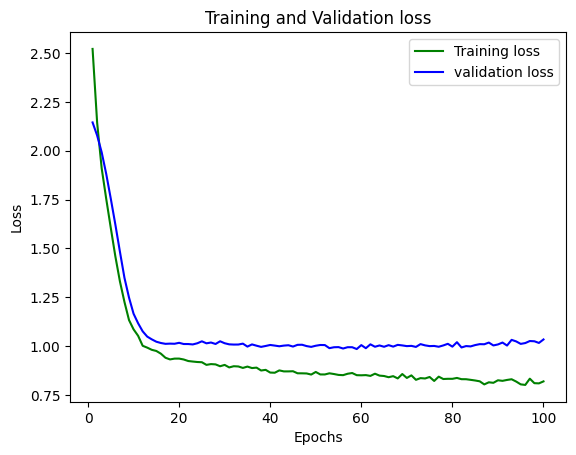

In [30]:
# 3. Model Training & Evaluation using Neural Network
# E. Plot visuals as in Q3.C and share insights about difference observed in both the models.
loss_train = model.history.history['loss']
loss_val = model.history.history['val_loss']
epochs = range(1,100+1)
plt.plot(epochs, loss_train, 'g', label='Training loss')
plt.plot(epochs, loss_val, 'b', label='validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

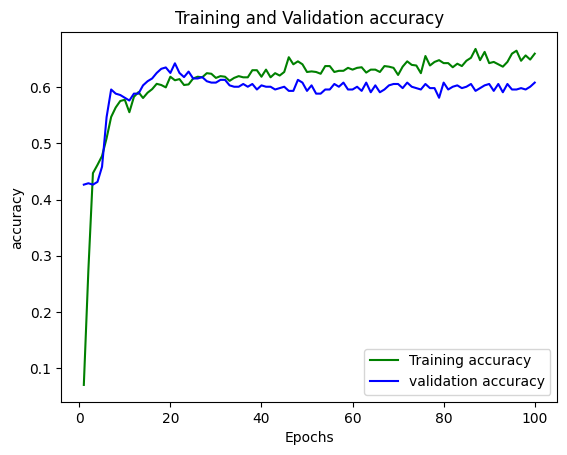

In [31]:
Acc_train = model.history.history['accuracy']
Acc_val = model.history.history['val_accuracy']
epochs = range(1,100+1)
plt.plot(epochs, Acc_train, 'g', label='Training accuracy')
plt.plot(epochs, Acc_val, 'b', label='validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

1. Accuracy improved by ~5% when additional hidden layer is introduced.
2. Loss in both training and testing data is gradual with higher batch size and whereas slope is steeper with batch size lower.

# PART B

DOMAIN: Autonomous Vehicles

• CONTEXT: A Recognising multi-digit numbers in photographs captured at street level is an important component of modern-day map
making. A classic example of a corpus of such street-level photographs is Google’s Street View imagery composed of hundreds of millions
of geo-located 360-degree panoramic images. The ability to automatically transcribe an address number from a geo-located patch of pixels and associate the transcribed number with a
known street address helps pinpoint, with a high degree of accuracy, the location of the building it represents. More broadly, recognising numbers in photographs is a problem of interest to the optical character recognition community.
While OCR on constrained domains like document processing is well studied, arbitrary multi-character text recognition in photographs is
still highly challenging. This difficulty arises due to the wide variability in the visual appearance of text in the wild on account of a large
range of fonts, colours, styles, orientations, and character arrangements.

The recognition problem is further complicated by environmental factors such as lighting, shadows, specularity, and occlusions as well as
by image acquisition factors such as resolution, motion, and focus blurs. In this project, we will use the dataset with images centred around
a single digit (many of the images do contain some distractors at the sides). Although we are taking a sample of the data which is simpler,
it is more complex than MNIST because of the distractors.

• DATA DESCRIPTION: The SVHN is a real-world image dataset for developing machine learning and object recognition algorithms with the
minimal requirement on data formatting but comes from a significantly harder, unsolved, real-world problem (recognising digits and
numbers in natural scene images). SVHN is obtained from house numbers in Google Street View images.

Where the labels for each of this image are the prominent number in that image i.e. 2,6,7 and 4 respectively.
The dataset has been provided in the form of h5py files. You can read about this file format here: https://docs.h5py.org/en/stable/
Acknowledgement: Yuval Netzer, Tao Wang, Adam Coates, Alessandro Bissacco, Bo Wu, Andrew Y. Ng Reading Digits in Natural Images with Unsupervised
Feature Learning NIPS Workshop on Deep Learning and Unsupervised Feature Learning 2011. PDF
http://ufldl.stanford.edu/housenumbers as the URL for this site.

• PROJECT OBJECTIVE: To build a digit classifier on the SVHN (Street View Housing Number) dataset.

In [35]:
# 1. Data Import and Exploration
# A. Read the .h5 file and assign to a variable.
import h5py
vehicles = h5py.File('Autonomous_Vehicles_SVHN_single_grey1.h5', 'r')

In [36]:
# 1. Data Import and Exploration
# B. Print all the keys from the .h5 file.
vehicles.keys()

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']>

In [37]:
# 1. Data Import and Exploration
# C. Split the data into X_train, X_test, Y_train, Y_test
X_train = vehicles['X_train'][:]
y_train = vehicles['y_train'][:]
X_test = vehicles['X_test'][:]
y_test = vehicles['y_test'][:]

In [38]:
# 2. Data Visualisation and preprocessing
# A. Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(42000, 32, 32)
(42000,)
(18000, 32, 32)
(18000,)


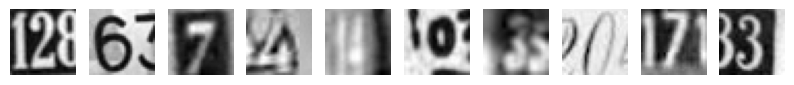

label for each image: [2 6 7 4 4 0 3 0 7 3]


In [42]:
# 2. Data Visualisation and preprocessing
# B. Visualise first 10 images in train data and print its corresponding labels.
def img_details(n):
    plt.figure(figsize=(n, 1))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X_train[i], cmap="gray")
        plt.axis('off')
    plt.show()
    print('label for each image: %s' % (y_train[0:n]))

img_details(10)

In [43]:
# 2. Data Visualisation and preprocessing
# C. Reshape all the images with appropriate shape update the data in same variable.
X_train = X_train.reshape(X_train.shape[0], 1024, 1)
X_test = X_test.reshape(X_test.shape[0], 1024, 1)

In [44]:
# 2. Data Visualisation and preprocessing
# D. Normalise the images i.e. Normalise the pixel values.
X_train = X_train / 255.0
X_test = X_test / 255.0

print('Resized Training data', X_train.shape, y_train.shape)
print('Resized Test data', X_test.shape, y_test.shape)

Resized Training data (42000, 1024, 1) (42000,)
Resized Test data (18000, 1024, 1) (18000,)


In [45]:
# 2. Data Visualisation and preprocessing
# E. Transform Labels into format acceptable by Neural Network
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [48]:
# 2. Data Visualisation and preprocessing
# F. Print total Number of classes in the Dataset.
print("The number of classes in this dataset:",y_test.shape[1])

The number of classes in this dataset: 10


In [57]:
# 3. Model Training & Evaluation using Neural Network
# A. Design a Neural Network to train a classifier.
def nn_new_model():
    model = Sequential()  
    model.add(Flatten())
    model.add(Dense(256, activation='relu')) ###Multiple Dense units with Relu activation
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(y_test.shape[1], activation='softmax'))
    return model

model = nn_new_model()

In [58]:
# 3. Model Training & Evaluation using Neural Network
# B. Train the classifier using previously designed Architecture (Use best suitable parameters).
grad_descnt = optimizers.Adam(lr=1e-3)
model.compile(loss='categorical_crossentropy', optimizer=grad_descnt, metrics=['accuracy'])
trained_hist = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=300, verbose=2)

Epoch 1/100
140/140 - 7s - loss: 2.2965 - accuracy: 0.1174 - val_loss: 2.2419 - val_accuracy: 0.1381 - 7s/epoch - 52ms/step
Epoch 2/100
140/140 - 2s - loss: 1.9975 - accuracy: 0.2883 - val_loss: 1.6921 - val_accuracy: 0.4244 - 2s/epoch - 17ms/step
Epoch 3/100
140/140 - 2s - loss: 1.6314 - accuracy: 0.4394 - val_loss: 1.5238 - val_accuracy: 0.4843 - 2s/epoch - 16ms/step
Epoch 4/100
140/140 - 2s - loss: 1.4877 - accuracy: 0.5030 - val_loss: 1.4109 - val_accuracy: 0.5352 - 2s/epoch - 17ms/step
Epoch 5/100
140/140 - 2s - loss: 1.3550 - accuracy: 0.5644 - val_loss: 1.2909 - val_accuracy: 0.5846 - 2s/epoch - 16ms/step
Epoch 6/100
140/140 - 3s - loss: 1.2621 - accuracy: 0.5975 - val_loss: 1.2367 - val_accuracy: 0.6036 - 3s/epoch - 24ms/step
Epoch 7/100
140/140 - 2s - loss: 1.1990 - accuracy: 0.6190 - val_loss: 1.1996 - val_accuracy: 0.6153 - 2s/epoch - 17ms/step
Epoch 8/100
140/140 - 2s - loss: 1.1627 - accuracy: 0.6309 - val_loss: 1.1190 - val_accuracy: 0.6470 - 2s/epoch - 15ms/step
Epoch 9/

In [59]:
# 3. Model Training & Evaluation using Neural Network
# C. Evaluate performance of the model with appropriate metrics.
final_result = model.evaluate(X_test, y_test, verbose=0)
print("Loss:", final_result[0])
print("Accuracy:", final_result[1])

Loss: 0.701050877571106
Accuracy: 0.8098333477973938


<Figure size 640x480 with 0 Axes>

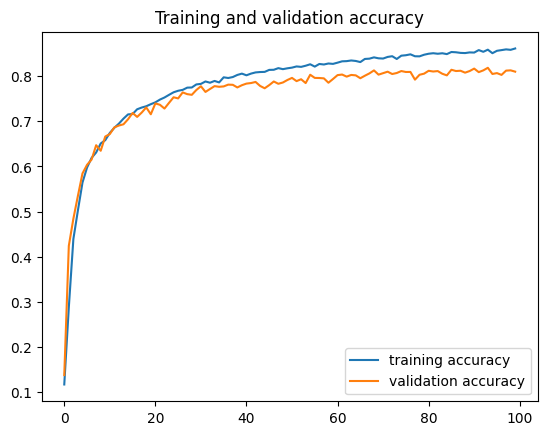

<Figure size 640x480 with 0 Axes>

In [61]:
# 3. Model Training & Evaluation using Neural Network
# D. Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.
accuracy = trained_hist.history['accuracy']
val_accuracy = trained_hist.history['val_accuracy']
loss = trained_hist.history['loss']
val_loss = trained_hist.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, label = 'training accuracy')
plt.plot(epochs, val_accuracy, label = 'validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc = 'lower right')
plt.figure()

Text(0.5, 1.0, 'Training and validation loss')

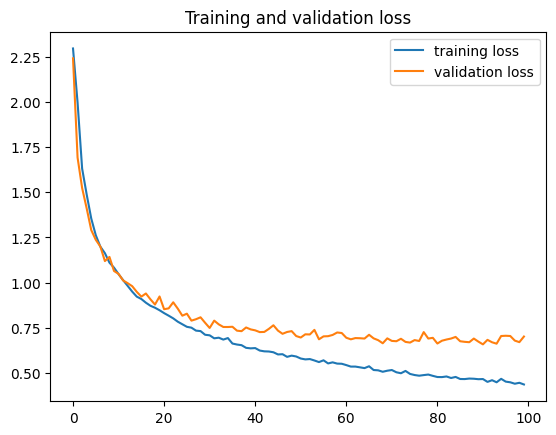

In [62]:
plt.plot( epochs, loss, label = 'training loss')
plt.plot(epochs, val_loss, label = 'validation loss')
plt.legend(loc = 'upper right')
plt.title('Training and validation loss')

# Observation:

1. There are 10 classes in the dataset.

2. We able to reach finally around 80% of accuracy.

3. After a certain point the model begins to overfit on our dataset.

4. With this amount of accuracy we are able to distinguish between the different digits in this dataset.